In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('../../datasets/auto-mpg.csv')
print('Missing values before cleaning:')
print(df.isnull().sum())
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
print('Missing values after type coercion:')
print(df.isnull().sum())
df = df.dropna().reset_index(drop=True)
df.head()

Missing values before cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64
Missing values after type coercion:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


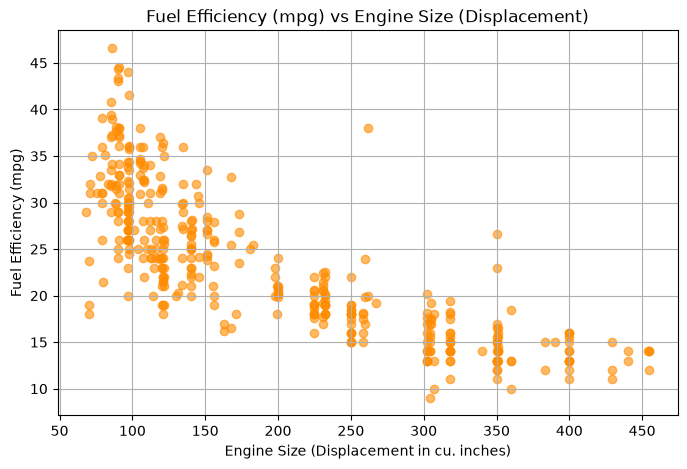

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['displacement'], df['mpg'], color='darkorange', alpha=0.6)
plt.title('Fuel Efficiency (mpg) vs Engine Size (Displacement)')
plt.xlabel('Engine Size (Displacement in cu. inches)')
plt.ylabel('Fuel Efficiency (mpg)')
plt.grid(True)
plt.show()

In [4]:
X = df[['displacement']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.06]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['displacement']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,35.88
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [5]:
b_0 = model.intercept_
b_1 = model.coef_[0]

print(f'Intercept (b_0): {b_0:.4f}')
print(f'Slope (b_1): {b_1:.4f}')
print(f'Regression Equation: mpg = {b_0:.4f} + ({b_1:.4f}) * Engine Size')
print(f'Interpretation: The negative slope ({b_1:.4f}) indicates that as engine size increases, fuel efficiency decreases. For every 1 cubic inch increase in engine displacement, fuel efficiency is estimated to drop by approximately {abs(b_1):.4f} mpg.')

Intercept (b_0): 35.8839
Slope (b_1): -0.0624
Regression Equation: mpg = 35.8839 + (-0.0624) * Engine Size
Interpretation: The negative slope (-0.0624) indicates that as engine size increases, fuel efficiency decreases. For every 1 cubic inch increase in engine displacement, fuel efficiency is estimated to drop by approximately 0.0624 mpg.


In [6]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print(f'Training Accuracy (R2 Score): {train_r2:.4f}')
print(f'Testing Accuracy (R2 Score): {test_r2:.4f}')

Training Accuracy (R2 Score): 0.6638
Testing Accuracy (R2 Score): 0.5715


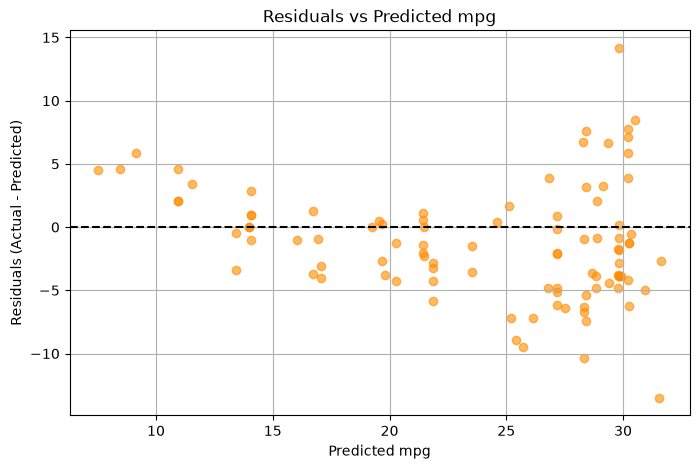

Discussion: The residual plot exhibits a distinct non-random parabolic shape. This indicates that the true relationship between displacement and mpg is non-linear, so while simple linear regression captures the overall negative relationship, a polynomial model would fit the data better.


In [7]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='darkorange', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals vs Predicted mpg')
plt.xlabel('Predicted mpg')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

print('Discussion: The residual plot exhibits a distinct non-random parabolic shape. This indicates that the true relationship between displacement and mpg is non-linear, so while simple linear regression captures the overall negative relationship, a polynomial model would fit the data better.')